# Pretraining data and evaluation

A language-model score is only meaningful with a documented dataset, split, tokenizer, checkpoint rule, and compute budget. This notebook turns those requirements into a compact reporting table and shows why perplexity and samples answer different questions.

In [1]:
import math
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.nn import functional as F
SEED = 7
random.seed(SEED)
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

Matplotlib is building the font cache; this may take a moment.


device: cpu


In [2]:
report = {'corpus': 'documented public-domain subset', 'tokenization': 'character IDs', 'train/validation split': 'ordered 90/10', 'context length': 32, 'parameters': 125000, 'optimizer': 'AdamW', 'checkpoint rule': 'lowest validation loss'}
for key, value in report.items():
    print(f'{key:24} {value}')

corpus                   documented public-domain subset
tokenization             character IDs
train/validation split   ordered 90/10
context length           32
parameters               125000
optimizer                AdamW
checkpoint rule          lowest validation loss


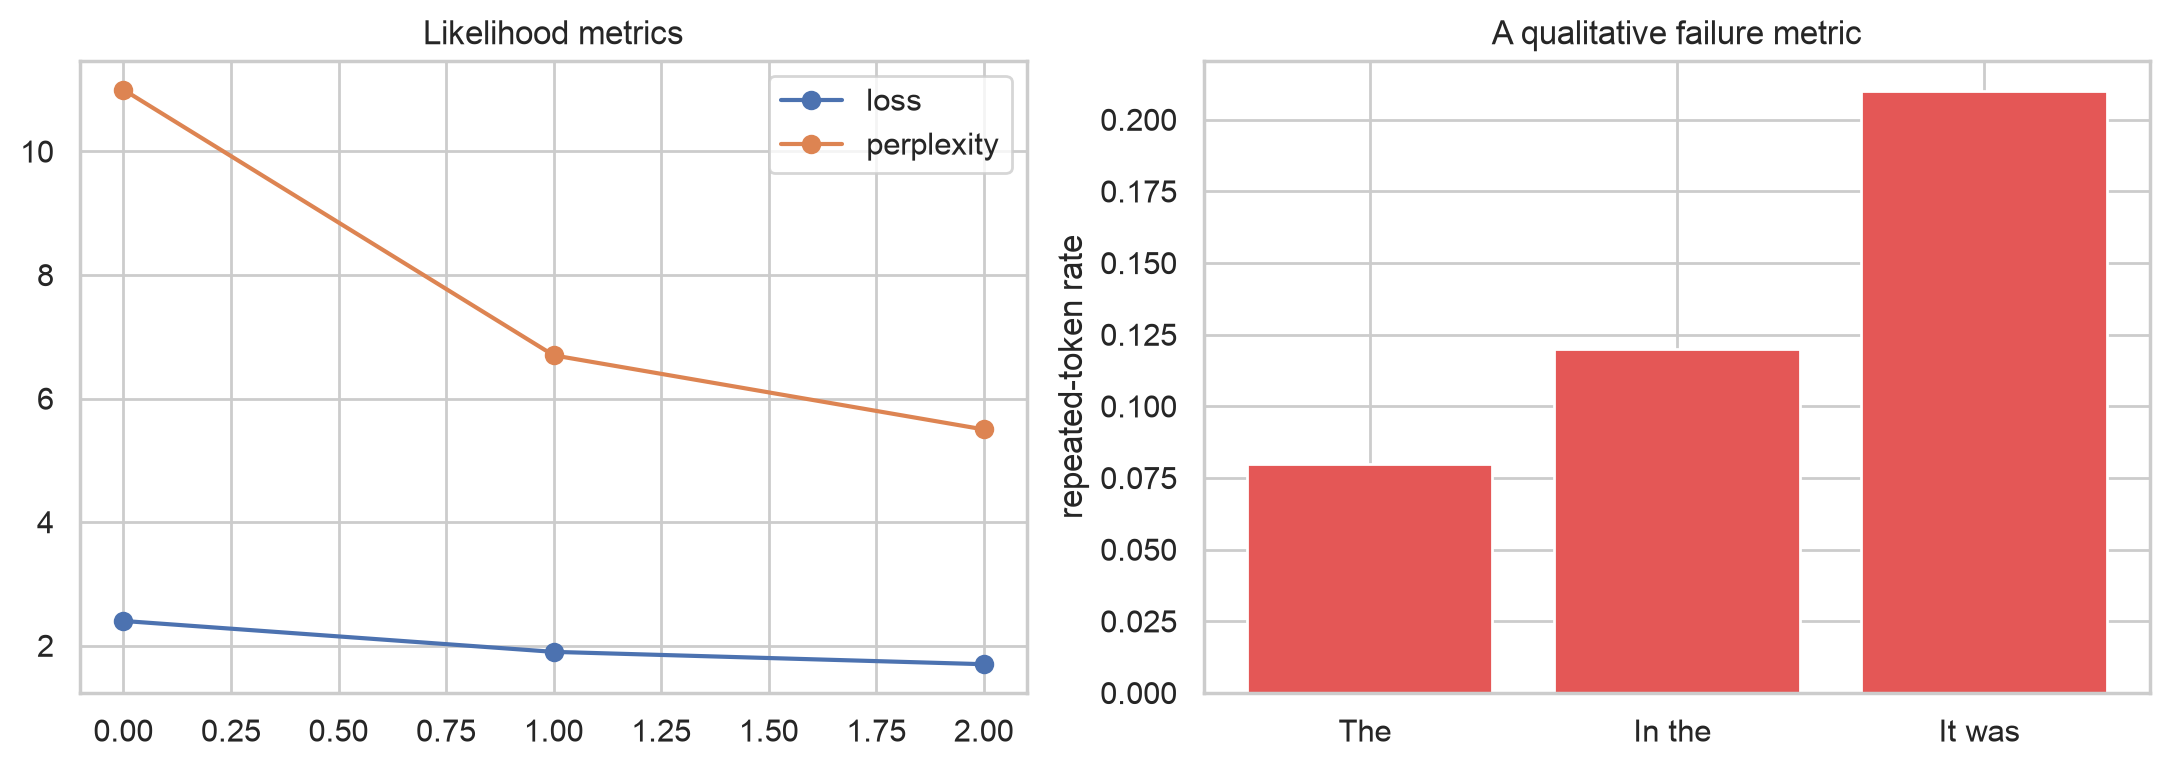

In [3]:
prompts = ['The ', 'In the ', 'It was ']
metrics = {'validation loss': [2.4, 1.9, 1.7], 'perplexity': [11.0, 6.7, 5.5], 'repetition rate': [0.08, 0.12, 0.21]}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(metrics['validation loss'], marker='o', label='loss')
axes[0].plot(metrics['perplexity'], marker='o', label='perplexity')
axes[0].set_title('Likelihood metrics')
axes[0].legend()
axes[1].bar(prompts, metrics['repetition rate'], color='#e45756')
axes[1].set_title('A qualitative failure metric')
axes[1].set_ylabel('repeated-token rate')
plt.tight_layout()
plt.show()

## Data is part of the result

The corpus determines which language patterns and facts are available to the model. A useful report names the source, license or access conditions, cleaning rules, deduplication policy, tokenizer, split, and number of training tokens. Without that information, a loss value cannot be reproduced or interpreted.

## Quantitative and qualitative evidence

Validation loss and perplexity measure average next-token likelihood. Fixed prompts expose behaviors that an average score can hide: repetition, truncation, malformed formatting, and sensitivity to prompt wording. The qualitative set must be fixed before looking at outputs so evaluation does not become selection of the most flattering examples.

## What perplexity cannot answer

Perplexity is not a direct measure of truthfulness, reasoning, safety, or usefulness. It can improve while a model becomes more repetitive, or worsen while a model becomes better at a narrow task. Evaluation needs a metric matched to the intended use.

Perplexity measures average held-out likelihood. It does not directly measure factuality, instruction following, originality, or whether a sample is useful to a person. A defensible evaluation reports both numerical metrics and a fixed qualitative set with failure categories.